### Plan B：对分割后的结构先进行降维处理，再建立链接关系
### 计算得到位移后再通过回复矩阵逐一恢复。
### 1、研究了SEREP降维方法 2、静态凝聚的降维方法。 都没有获得期望的结果

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

### 经典水弹性计算波浪问题

In [2]:
# setting initial parameter, reading mass and stiffness matrix
num_nodes = 403 # 63 793
master_nodes = DM_A.calculate_node_positions(214,6,5) 
master_nodes_length = 10
number = 300
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"))
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_STIF1.mtx' 
omega = dataset.omega.values

In [3]:
# read mass and stiffness matrix
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
#MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
MR,KR,T = SEREP.static_condensation(k, M, MasterDofs, SlaveDofs)
# node displacement

In [4]:
# 合并质量和刚度矩阵、建立链接关系
fem_mass = np.block([
    [MR, np.zeros((25,25))],
    [np.zeros((25,25)), MR]
    ])
fem_kiffness = np.block([[KR, np.zeros((25,25))],[np.zeros((25,25)), KR]])


def apply_hinge_joint(fem_kiffness, k_hinge):
    """
    将铰链关节刚度矩阵应用到全局刚度矩阵中。
    
    参数:
    fem_kiffness (numpy.ndarray): 全局刚度矩阵。
    k_hinge (float): 铰链关节的刚度。
    
    返回:
    numpy.ndarray: 更新后的全局刚度矩阵。
    """
    # 定义铰链关节的刚度矩阵
    KC = np.diag([k_hinge, k_hinge, k_hinge, k_hinge, 0])  # 铰链关节的刚度矩阵
    negative_KC = -KC

    # 具体的节点（可以根据需要调整）
    node1 = 5
    node2 = 6

    # 计算全局刚度矩阵中对应节点的索引位置
    index1 = (node1 - 1) * 5  # 节点1的自由度起始索引
    index2 = (node2 - 1) * 5  # 节点2的自由度起始索引

    # 将铰链的自刚度添加到节点
    fem_kiffness[index1:index1+5, index1:index1+5] += KC
    fem_kiffness[index2:index2+5, index2:index2+5] += KC

    # 实现铰链关节节点之间的相互作用
    fem_kiffness[index1:index1+5, index2:index2+5] += negative_KC
    fem_kiffness[index2:index2+5, index1:index1+5] += negative_KC
    
    return fem_kiffness

fem_kiffness = apply_hinge_joint(fem_kiffness, k_hinge=10e15)


In [5]:
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# node displacement
i = 0
# read hydrodynamic data
added_mass = dataset['added_mass'][i].values
radiation_damping = dataset['radiation_damping'][i].values
# hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values

# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])

F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)

# Generate the system matrices
mass = added_mass + fem_mass
damping = radiation_damping
stiffness =  hydrostatic_stiffness + fem_kiffness
# F_w = reverse_load_matrix(F_w, num_dofs=5)
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])


In [6]:
global_displacement_disorder_A = T @ master_displacement[0:25]
global_displacement_disorder_B = T @ master_displacement[25:50]
# Reorder global displacement under order
global_displacement_A = SEREP.reorder_displacement_matrix(global_displacement_disorder_A, MasterDofs, SlaveDofs)
global_displacement_B = SEREP.reorder_displacement_matrix(global_displacement_disorder_B, MasterDofs, SlaveDofs)
# 保存数据
mid_A = global_displacement_A[2::5,:]
mid_B = global_displacement_B[2::5,:]

In [7]:
mid_A = mid_A.reshape(13,31)
mid_B = mid_B.reshape(13,31)

In [8]:
combined_model = np.hstack((mid_A, mid_B))
modified_model = np.delete(combined_model, 30, axis=1)

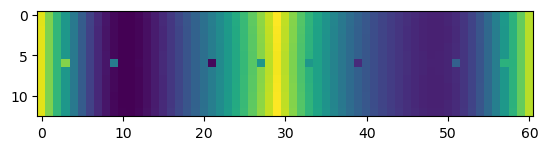

In [9]:
plt.imshow(abs(modified_model))

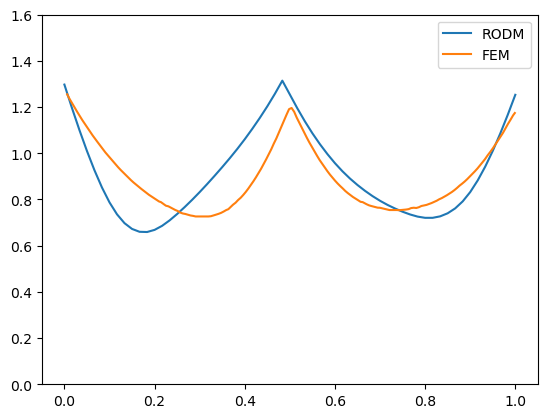

In [10]:
x = np.linspace(0, 1, 61)
plt.plot(x, abs(modified_model[7,:]))
import pandas as pd
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Default Dataset.csv')
plt.plot(df.iloc[:, 0],df.iloc[:, 1])
plt.ylim(0,1.6)
plt.legend(['RODM','FEM'])